# Real Estate Price Prediction - Exploratory Data Analysis
This notebook provides a detailed analysis of the property dataset to identify patterns, outliers, and key features for model development.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [31]:
df = pd.read_csv('../data/raw/data_master.csv')
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1096, 10)


,price,bedrooms,bathrooms,livingarea,propertytype,listingstatus,vegas_district,latitude,longitude,snapshot_date
0,7100000.00,5,8.00,10153.00,SINGLE_FAMILY,FOR_SALE,Enterprise,35.98,-115.19,2026-02-20
1,534900.00,3,3.00,2122.00,SINGLE_FAMILY,FOR_SALE,Centennial,36.30,-115.32,2026-02-14
2,459900.00,3,3.00,1547.00,SINGLE_FAMILY,FOR_SALE,Mountains Edge,36.00,-115.26,2026-02-23
3,320000.00,3,3.00,1202.00,SINGLE_FAMILY,FOR_SALE,North Las Vegas,36.24,-115.07,2026-02-09
4,675000.00,5,3.00,3037.00,SINGLE_FAMILY,FOR_SALE,Centennial,36.29,-115.32,2026-02-20


In [32]:
# Summary statistics for numerical features
df.describe()

,price,bedrooms,bathrooms,livingarea,latitude,longitude,snapshot_date
count,1096.00,1096.00,1096.00,1096.00,1096.00,1096.00,1096
mean,842150.66,3.53,2.97,2339.41,36.15,-115.23,2026-02-16 17:52:07.007299328
min,2000.00,1.00,1.00,593.00,35.96,-115.38,2026-02-07 00:00:00
25%,380000.00,3.00,2.00,1436.00,36.10,-115.30,2026-02-11 00:00:00
50%,495000.00,3.00,3.00,1929.00,36.15,-115.25,2026-02-17 00:00:00
75%,700000.00,4.00,3.00,2745.50,36.21,-115.16,2026-02-22 00:00:00
max,30000000.00,14.00,17.00,23748.00,36.34,-115.01,2026-02-23 00:00:00
std,2010890.67,1.17,1.31,1710.39,0.09,0.09,NaN


## 1. Target Variable Analysis: Price

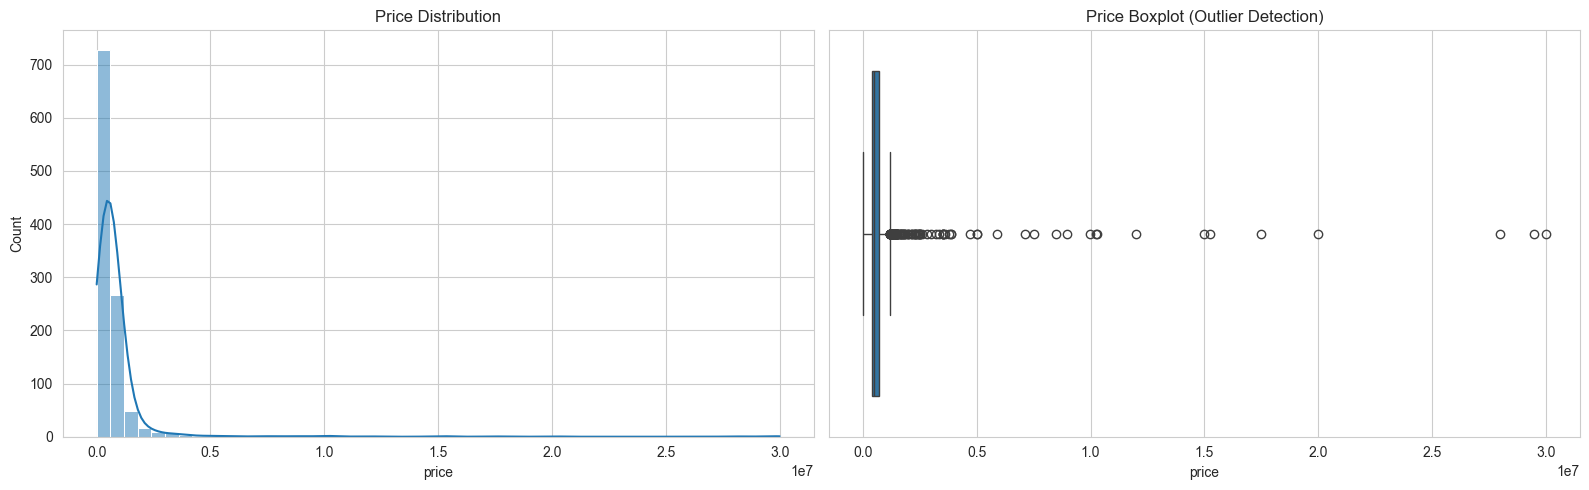

Skewness: 10.323184645220621


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Price Distribution')

# Boxplot to identify outliers
sns.boxplot(x=df['price'], ax=axes[1])
axes[1].set_title('Price Boxplot (Outlier Detection)')

plt.tight_layout()
plt.show()

# Skewness analysis
print(f"Skewness: {df['price'].skew()}")

## 2. Numerical Features Analysis

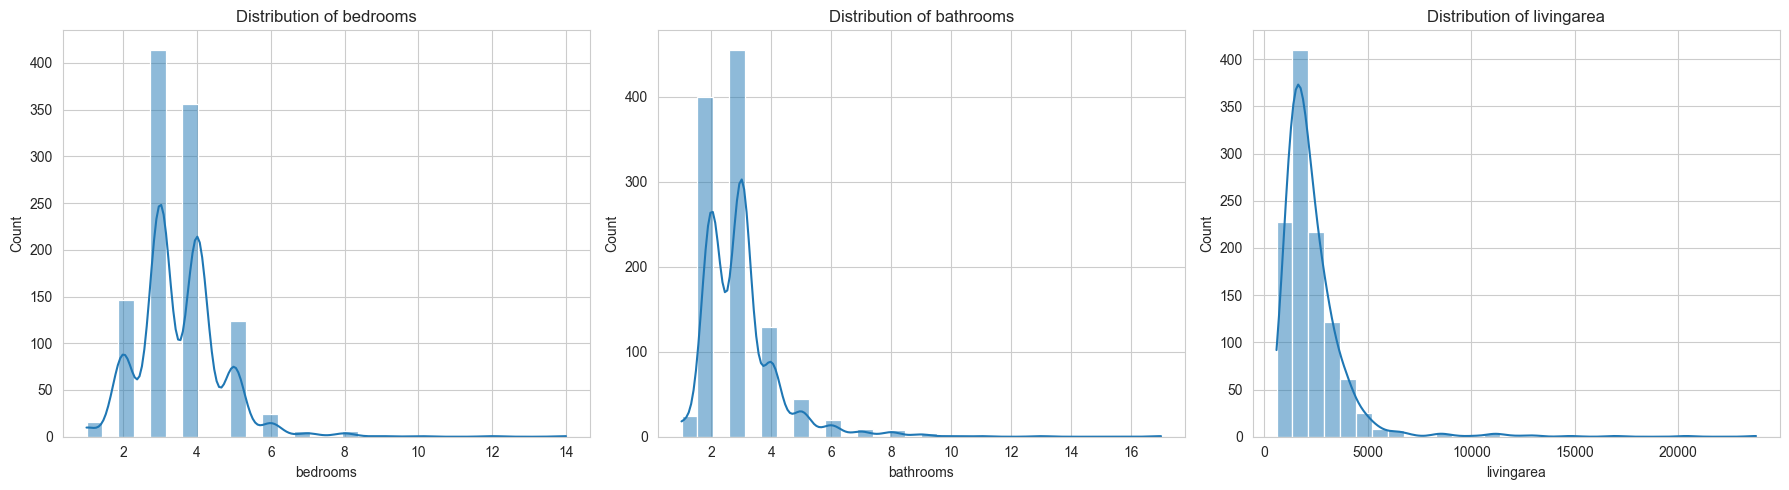

In [34]:
num_cols = ['bedrooms', 'bathrooms', 'livingarea']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

## 3. Categorical Features Analysis

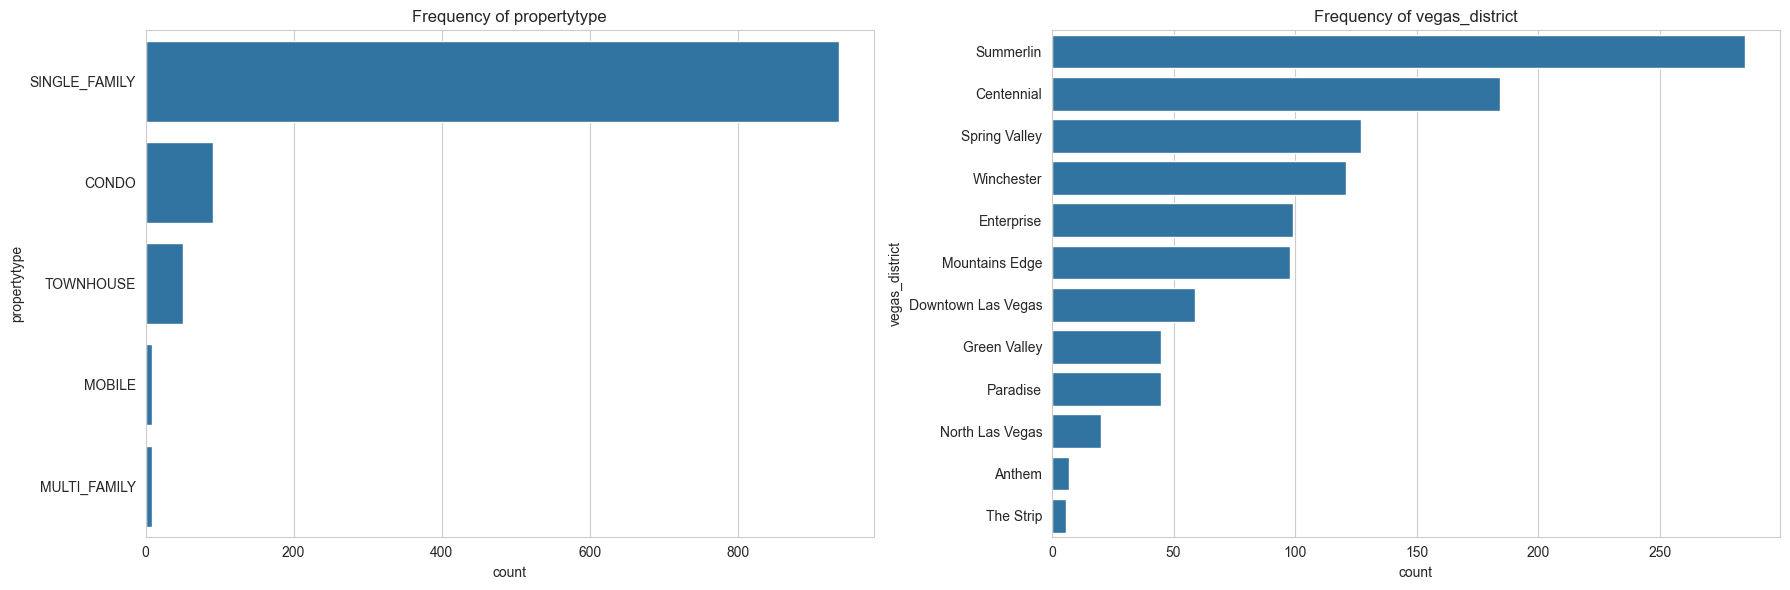

In [35]:
cat_cols = ['propertytype', 'vegas_district']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i])
    axes[i].set_title(f'Frequency of {col}')

plt.tight_layout()
plt.show()

## 4. Relationship with Price

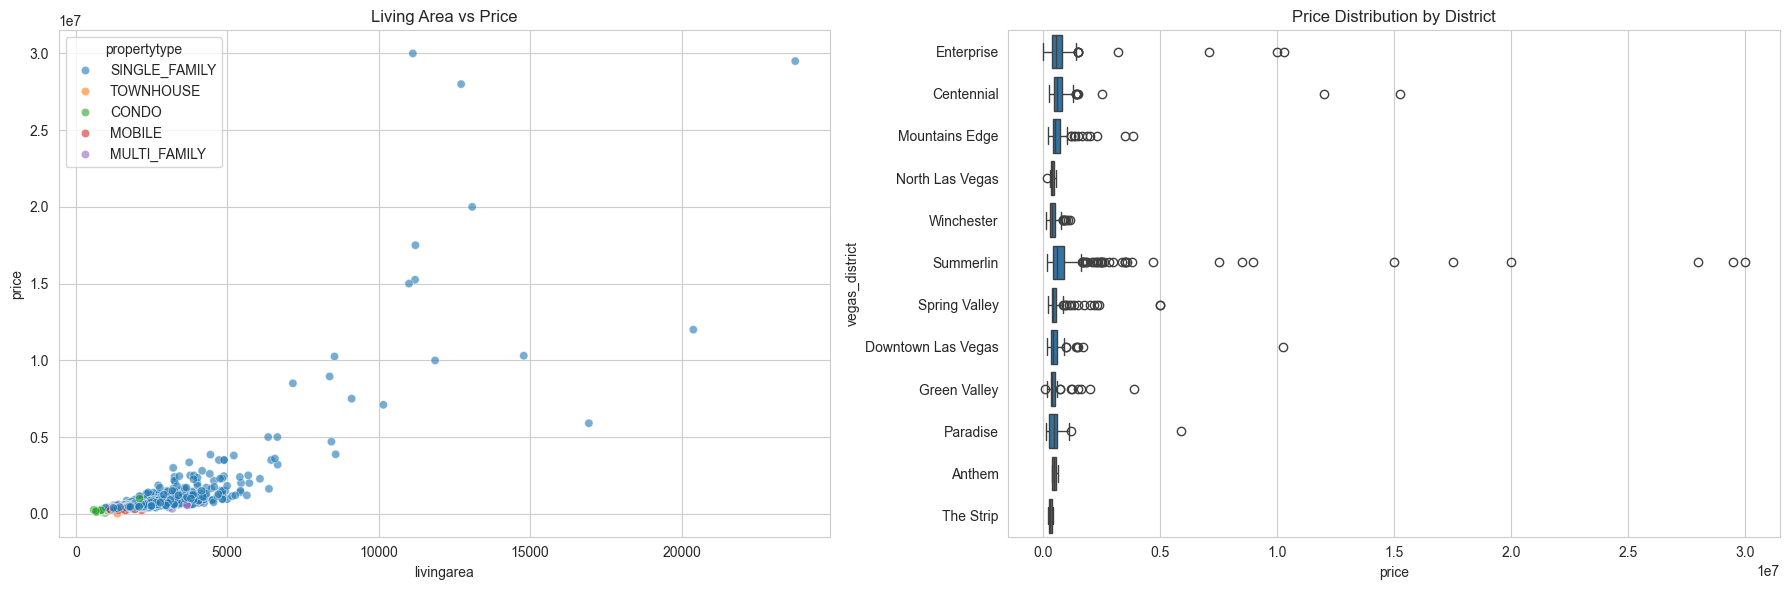

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Living Area vs Price
sns.scatterplot(data=df, x='livingarea', y='price', hue='propertytype', alpha=0.6, ax=axes[0])
axes[0].set_title('Living Area vs Price')

# District vs Price
sns.boxplot(data=df, x='price', y='vegas_district', ax=axes[1])
axes[1].set_title('Price Distribution by District')

plt.tight_layout()
plt.show()

## 5. Correlation Heatmap

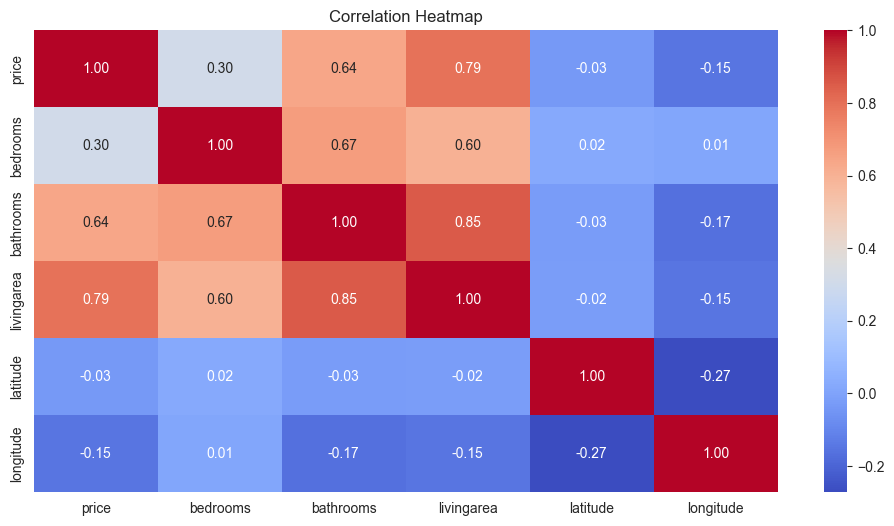

In [37]:
# Correlation of numeric features
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## 6. Geospatial Price Distribution

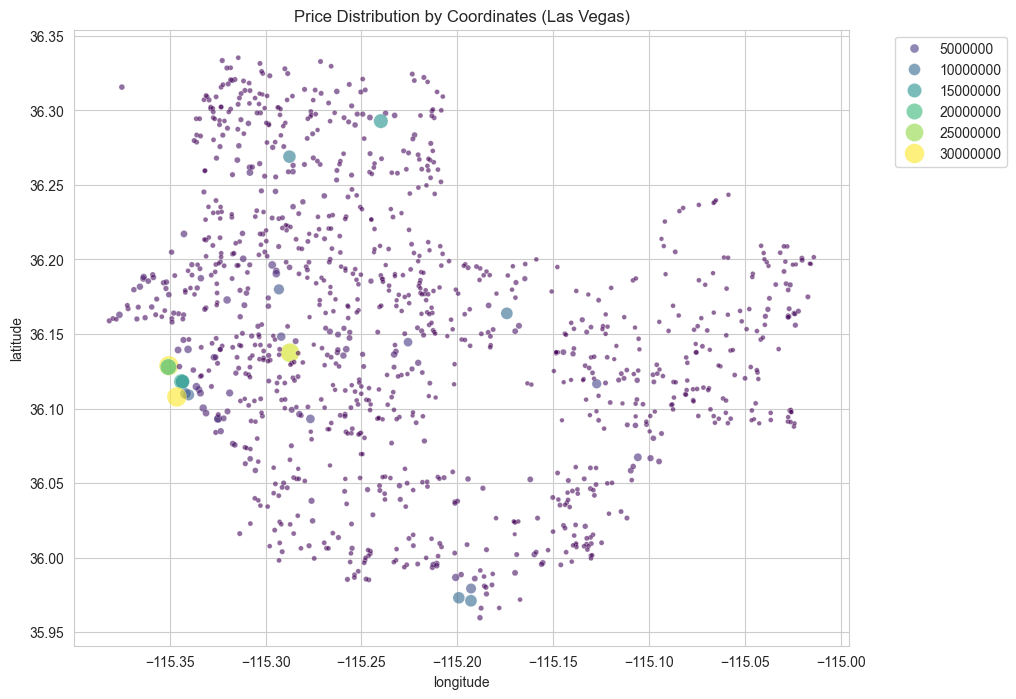

In [28]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='price', size='price', 
                palette='viridis', sizes=(10, 200), alpha=0.6)
plt.title('Price Distribution by Coordinates (Las Vegas)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

## 7. Key Findings & Implications for Modeling
- **Outliers**: Price and Living Area have significant outliers (Luxury properties). Consider robust scaling or log-transformation.
- **Feature Engineering**: 'Vegas District' and 'Property Type' are strong categorical indicators for price.
- **Multicollinearity**: Bedrooms and Bathrooms are likely correlated with Living Area.
- **Target Leakage**: Ensure 'Listing Status' is used as a filter or categorical feature, not a leakage source.

## 8. Insights & Modeling Recommendations (Actionable)

### Snapshot / dataset at-a-glance
- Rows: 1,096; Columns (features considered): 10  
- Date range: 2026-02-07 → 2026-02-23 (12 unique snapshot_date values) — short temporal coverage => temporal generalization risk.
- No missing values reported.

### Target (price) — key diagnostics
- Distribution: extremely right-skewed (skew ≈ 10.32). Log1p(price) skew ≈ 1.27.
- Summary:
    - Median: $495,000
    - 95th percentile: $1,712,500
    - 99th percentile: ≈ $9,001,000
    - Max: $30,000,000
- IQR: Q1 = $380,000, Q3 = $700,000, IQR = $320,000 → 114 IQR outliers identified.
- Price-per-sqft extremes: p01 ≈ 148, p99 ≈ 896; 10 rows with ppsf > 1000 and 2 rows with ppsf < 80 (candidates for label/noise inspection).

### Strong predictors & multicollinearity
- Top correlations with price: price_per_sqft (0.87), livingarea (0.79), bathrooms (0.64), bedrooms (0.30).
- Multicollinearity signals:
    - bathrooms vs livingarea: corr ≈ 0.85
    - bedrooms vs bathrooms: corr ≈ 0.67

### Categorical structure & leakage
- propertytype is imbalanced (SINGLE_FAMILY dominates).
- vegas_district contains meaningful signal (median spread across districts ≈ $308.5k).
- listingstatus is constant (FOR_SALE) — drop it (no predictive value).

---

## Modeling recommendations (concise)

1. Target
     - Model y = log1p(price). Invert predictions with expm1 at inference.
2. Metrics
     - Prefer robust metrics: MAE, Median Absolute Error. Optionally use RMSLE on original-scale outputs.
3. Features to keep / drop
     - Keep: propertytype, vegas_district, latitude, longitude, livingarea, bedrooms, bathrooms.
     - Drop: listingstatus (near-constant).
4. Rare categories
     - Group very-rare levels into "Other" or use target/impact encoding with cross-validation (to avoid leakage).
5. Feature engineering
     - price_per_sqft (diagnostic), beds_per_bath, bath_per_sqft, log(livingarea), geo clusters / bins, snapshot_date-derived features (age-of-listing if available).
6. Multicollinearity handling
     - Either keep correlated features (tree models handle them) or apply dimensionality reduction / remove one of highly collinear pairs for linear models.
7. Outliers & label noise
     - Audit extreme rows (very high price, extreme ppsf). Options: winsorize, robust loss (Huber, Quantile), or keep but ensure robust metrics.
8. Validation
     - Use time-aware splits by snapshot_date (train on older snapshots, validate on newer) to avoid optimistic leakage given short date span.
9. Baseline & sanity checks
     - Fit a simple baseline (LightGBM / CatBoost) on log1p(price) to check feature importance, residuals, and district × propertytype interactions.

---

## Pre-training EDA checklist (high-priority)
- Residual / outlier audit table (rows with extreme price, extreme sqft, extreme ppsf).
- Feature importance from a simple gradient-boost baseline on log-price.
- Interaction plots: district × propertytype (median, counts, uncertainty bands).
- Leakage check: ensure no post-listing or derived target columns leak into training.

---

Quick implementation notes
- Train on log1p(price). Predict with model and apply expm1 to outputs for business-facing metrics.
- Use RobustScaler where appropriate and robust losses if many extreme tails are retained.